In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("cs1090a_hw0.ipynb")

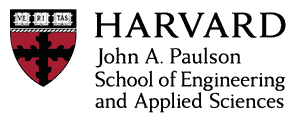

# CS1090A Introduction to Data Science

## Homework 0

**Harvard University**<br/>
**Fall 2026**<br/>
**Instructors**: Pavlos Protopapas & Kevin Rader

---

## What HW0 is for

CS1090A attracts students with very different backgrounds — some with years of programming
behind them, some fluent in statistics and newer to Python. Homework 0 is how you find out
where you stand against the prerequisites, while there is still time to act on it.

You are not expected to recall all of it from memory; looking things up is the job. But if
large parts feel not just rusty but genuinely unfamiliar, consider spending more time with the
prerequisite material and taking CS1090A in a later semester.

## How this is graded

**On completion.** Attempt every question in a block and the block is yours. Mistakes are fine.
Leaving sections blank is not.

| Block | Where it is graded | Points |
| :---- | :----------------- | -----: |
| Part 2 — Python Poetry Challenge | **Homework 0 — Notebook 📔** (autograded + TF) | 35 |
| Part 3 — Math and Statistics | **Homework 0 — Notebook 📔** (autograded + TF) | 35 |
| Your written work and the Reflection | **Homework 0 — PDF 📄** (read by a TF) | 30 |

Part 1 is not graded directly. It is what makes the rest of the notebook run.

**The correctness tests are worth zero points.** They run and you see every result, but they
cannot move your score. What you get back instead is a **diagnostic**: every question marked
*solid*, *shaky* or *not attempted*. That report is the point of the assignment — and it is
built from what you wrote, so an answer you didn't understand produces a report about somebody
who isn't you.

**Work individually**, unlike HW1–HW5. HW0 is 1% of the course grade, individual, and **late days do not
apply**. You may resubmit either file on Gradescope as often as you like before the deadline.

## What to submit

**Two files, and you have to submit both.** They are the same document in two formats, but they
are two separate Gradescope assignments, graded separately and due at the same time.

| Upload | What it is | Worth | Graded by |
| :----- | :--------- | ----: | :-------- |
| **Homework 0 — Notebook 📔** | this notebook, `cs1090a_hw0.ipynb` | 70 | an autograder, within a couple of minutes |
| **Homework 0 — PDF 📄** | a PDF of the same notebook | 30 | a TF, who reads the whole thing |

On the PDF, Gradescope asks you to mark which pages six sections of the assignment are on. The
closing cell of this notebook shows you exactly what to mark.

**Your notebook has to run, from the top to the bottom, and be submitted with its output.**
Before you export or upload anything, run `Kernel → Restart Kernel and Run All Cells`, then save.
A notebook that was never run, whose cells were run out of order, or that **stops on a cell that
raises** — `Run All` halts there and everything below stays blank — **scores zero on the notebook
assignment**, however much is written in it.

Running is not the same as being right. A wrong answer costs you nothing; a cell that raises an error that stops execution
costs you the rest of the notebook. If you cannot fix one, put a plausible value in it and say in
a comment what you were attempting — then the cells below it have something to work with and your
notebook reaches the end. Resubmission is unlimited, so this costs nothing but the upload.

`SETUP.md`, next to this notebook, has the details: how to run it, how to export the PDF, and
how the page marking works.

# Part 1: Setting the Stage <a id="part1"></a>

Your first task is the one this course never stops needing: **a working Python environment on a
machine you control.** You will be given environments you can reach from a browser, but everyone
is expected to be able to build a comparable one themselves.

This part asks you no questions. The check is simply whether the cell at the end of it runs — if
your environment isn't built, nothing else in this notebook will work either.

You need a terminal, and enough comfort with the
[filesystem](https://en.wikipedia.org/wiki/File_system) to move around and read and write files.

## Why Python?

Python has a clean, readable syntax — "pseudocode you can run" — and a huge scientific ecosystem
on top of a large [standard library](https://docs.python.org/3/library/index.html). That
combination is why it dominates data science.

## The shell and the terminal

Most operating systems already ship some Python. You can ask your
[**shell**](https://en.wikipedia.org/wiki/Shell_%28computing%29) — the program that gives you
access to the operating system's services — through a
[terminal](https://en.wikipedia.org/wiki/Terminal_emulator):

```sh
which python
python --version
```

`which` reports the path of the executable that would run if you typed that name, by searching
the [`PATH`](https://en.wikipedia.org/wiki/PATH_(variable)) environment variable.

> ❗ On some systems you need `python3` rather than `python`.
> 💡 Prefixing a command with `!` runs it in the shell from inside a notebook.

> **Windows users:** [PowerShell](https://docs.microsoft.com/en-us/powershell/) works for most
> of this course but lacks many standard UNIX commands. Consider
> [Git Bash](https://gitforwindows.org/), or better,
> [Windows Subsystem for Linux](https://learn.microsoft.com/en-us/windows/wsl/about) (WSL).

In [ ]:
!python --version

You want 3.10 or newer; the course environment uses 3.12. If `which` found nothing, or the
version is older, [install Python](https://realpython.com/installing-python/) first.

## Virtual environments

Beyond the standard library we want third-party packages, and *how* you install them matters:

1. Different projects need conflicting versions of the same package, and those versions cannot
   coexist in one installation.
2. Your operating system may itself depend on Python; changing the system installation can break
   things you did not intend to touch.
3. Results are not reproducible unless the exact package versions that produced them are recorded.

A [virtual environment](https://docs.python.org/3/library/venv.html#venv-def) solves all three:
a self-contained directory holding an interpreter plus its own packages.

This course recommends [uv](https://docs.astral.sh/uv/). Install it, then, **from the folder
holding this notebook's `requirements.txt`**:

```sh
uv venv
uv pip install -r requirements.txt
source .venv/bin/activate     # Windows: .venv\Scripts\activate
```

Those first two commands are run once per environment. `deactivate` reverses the third.

## Jupyter

Most course material is delivered as [Jupyter notebooks](https://jupyter.org/) — runnable code
embedded in formatted prose. The `requirements.txt` you just installed includes JupyterLab, so
with the environment activated:

```sh
jupyter lab
```

or, without activating it first, `uv run jupyter lab`.

### Check your environment

Run the cell below. It imports the packages this course needs and reports the Python that is
actually running this notebook — which is not always the one `which python` finds, since the
kernel has its own interpreter.

**If it raises, your environment is not ready.** Go back and build it before continuing;
everything from Part 2 onward depends on it.

In [ ]:
# Provided — just run it.
import sys
from importlib.metadata import version

import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

print(f"Python  {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")
print(f"running {sys.executable}")
for _pkg in ("numpy", "scipy", "matplotlib", "pandas"):
    print(f"  {_pkg:<12} {version(_pkg)}")

*`pandas` is course content rather than a prerequisite — you are not expected to know it yet. It
is checked here only so you find out now if your environment is incomplete.*

# Part 2: Python Poetry Challenge <a id="part2"></a>

CS1090A assumes you already write Python. To find out whether you do, you'll build a **random
poem generator** from a collection of [Emily Dickinson](https://en.wikipedia.org/wiki/Emily_Dickinson)
poems published by [Project Gutenberg](https://www.gutenberg.org/).

Skills exercised: file I/O, strings, slicing, lists, dictionaries, logical operators,
iteration, functions, classes, reading documentation, and debugging.

**This part is a chain** — each question consumes the previous one's output, so an error early on
could propagate through the rest of Part 2. For this reason, every question is followed by a
**checkpoint** cell that reports how your answer compares to ours and then hands you a known-good
value to carry forward.

The checkpoints come from `hw0_utils.py`, sitting next to this notebook. It contains reference
implementations of everything you're about to write. You can open it. But bear in mind what you'd
be trading: a copied solution (besides being easy to detect) defeats the purpose of HW0, which is to help you assess your preparedness for the course.
Use `compare()` to find your bug — that is what it's for.

In [ ]:
import hw0_utils

<div class='exercise' id='q2.1'><b>Q2.1 — Read in the file</b></div>

The document is a digital transcription of
[three early Dickinson collections](https://www.gutenberg.org/ebooks/12242) whose U.S.
copyright has expired. It ships with this assignment as plain text at `data/pg12242.txt`. (The
opaque filename is a condition of the
[Project Gutenberg License](https://gutenberg.org/policy/license.html) included in the file.)

Read the whole file into a string called `text`. Then slice out the first 10,000 characters as
`head` and the last 25,000 as `tail`.

> **Keep your output short.** 📜😱<br/>
> `text` is nearly 200,000 characters, and one of your two submissions is a **PDF a TF has to
> read**. Print slices, never whole documents. Widen a slice while you are exploring if you need
> to, then narrow it again before you export. If a cell genuinely needs to show more than ~15
> lines, right-click it and choose **Enable Scrolling for Outputs**.

In [ ]:
DATA_PATH = "data/pg12242.txt"

with open(DATA_PATH, encoding="utf-8") as f:
    text = ...

head = ...
tail = ...

In [ ]:
# The start of the document: Project Gutenberg's header, then the first preface.
# Widen this slice while you explore; put it back before you export the PDF.
print(head[:800])

In [ ]:
# The end of the document: the last poems, then the license
print(tail[-800:])

In [ ]:
grader.check("q2.1")

<div class='exercise' id='q2.2'><b>Q2.2 — Find where each series begins and ends</b></div>

Reading the `head` and `tail` you just printed, the document has this structure:

- Project Gutenberg: header and metadata
- Series 1: preface
- **Series 1: poems**
- Series 2: preface
- **Series 2: poems**
- Series 3: preface
- **Series 3: poems**
- Project Gutenberg: footer and license

We want only the bold parts. Recognizing and exploiting structure like this is a large part of
data science, and the structure here is marked by three strings that occur nowhere else in a
misleading position:

In [ ]:
PREFACE_MARKER = "POEMS\n"          # every preface opens with this line
FIRST_POEM_MARKER = "I. "           # the first numbered poem after a preface
LICENSE_MARKER = "End of Project Gutenberg"   # the license block at the end

Write `series_bounds(s, search_from=0)`, which returns the `(start, end)` character indices of
the next series' **poem block** at or after `search_from`:

- `start` is the index of the first numbered poem (`FIRST_POEM_MARKER`) that follows the next
  preface (`PREFACE_MARKER`).
- `end` is the index of the preface after that — **or**, when there is no further preface, the
  index of the license.

That second case is the only real wrinkle: the third series is followed by the license, not by
another preface.

> **Hints:**
> - `str.index(sub, start)` returns the index of the first occurrence of `sub` at or after
>   `start`, and raises `ValueError` if there is none.
> - `str.find(sub, start)` does the same but returns `-1` instead of raising — handy when
>   "there is none" is a case you want to handle rather than an error.

The docstring gives you the answer for the first series, so you can check yourself immediately.

In [ ]:
def series_bounds(s: str, search_from: int = 0) -> tuple[int, int]:
    '''
    Returns: (start, end) indices of the next series' poem block at or after `search_from`
    Ex:
        series_bounds(text) -> (6714, 49215)
    '''
    ...

In [ ]:
# Apply your function three times, walking forward through the document.
series = []
position = 0
for _ in range(3):
    start, end = series_bounds(text, position)
    series.append(text[start:end].strip())
    position = end

for i, s in enumerate(series, start=1):
    print(f"series {i}: {len(s):,} characters, starts {s[:40]!r}")

In [ ]:
grader.check("q2.2")

**Checkpoint.** The three series get joined into one string, and the single bracketed editor's
note in the first poem — the only one in the document — is removed along with the blank line
beneath it. That cleanup is done for you.

In [ ]:
poems_text = hw0_utils.canonical_poems_text(text)

print(hw0_utils.compare("series", tuple(series), text))
print(f"\npoems_text: {len(poems_text):,} characters\n")
print(poems_text[:300], "...")

<div class='exercise' id='q2.3'><b>Q2.3 — Remove the section titles and poem numbers</b></div>

More of what remains isn't Dickinson's: the editors divided each series into sections
(`I. LIFE.`, `II. LOVE.`, …) and numbered the poems within them (`I.`, `II.`, `III.`, …). Every
one of those lines begins with a [roman numeral](https://en.wikipedia.org/wiki/Roman_numerals).

**First**, write `startswith_roman(line)`, returning `True` when `line`'s first
whitespace-delimited token is a roman numeral. A token qualifies when all three hold:

1. it ends with a `.`
2. the part before that `.` is **not empty**
3. every character of that part is one of `I`, `V`, `X`, `L`, `M`

> `C` (100) and `D` (500) are deliberately excluded. Including them would classify `DID.` and
> `COME.` as numerals and delete real poem lines; the largest numeral here is nowhere near 100.
> Condition 2 matters too — a line that begins with a bare `.` is not a numbered section, and
> `all()` of an empty sequence is `True`, so you have to rule it out on purpose.

The function does not need to reject *invalid* numerals such as `IIIV.`; no such string occurs.

**Then** use it to build `poems_text_nonum`: `poems_text` with every such line removed, and any
leading or trailing whitespace stripped from the result.

In [ ]:
def startswith_roman(line: str) -> bool:
    '''
    Returns: True if `line` starts with a roman numeral and False otherwise
    Ex:
        startswith_roman("III. NATURE.")             -> True
        startswith_roman("I'm nobody! Who are you?") -> False
    '''
    ...

In [ ]:
poems_text_nonum = ...

print(poems_text_nonum[:400])

In [ ]:
grader.check("q2.3")

**Checkpoint.**

In [ ]:
poems_text_nonum_ref = hw0_utils.canonical_poems_text_nonum(text)
print(hw0_utils.compare("poems_text_nonum", poems_text_nonum, text))
poems_text_nonum = poems_text_nonum_ref

<div class='exercise' id='q2.4'><b>Q2.4 — Create a list of poems</b></div>

Now split the text into individual poems. To see the structure you need to see the whitespace,
so print the raw string rather than the rendered one:

In [ ]:
from pprint import pprint

pprint(poems_text_nonum[:1500])

Consecutive poems are separated by runs of newlines, and exploring the text shows the minimum
run between two poems is **six**. Use that to build `poem_list`: the poems in the order they
appear, each stripped of leading and trailing whitespace.

> **Hint:** splitting will produce some empty strings. Leave them out.

In [ ]:
poem_list = ...

print(f"There are a total of {len(poem_list)} poems.\n")
print(poem_list[109])

In [ ]:
grader.check("q2.4")

**Checkpoint.**

In [ ]:
poem_list_ref = hw0_utils.canonical_poem_list(text)
print(hw0_utils.compare("poem_list", poem_list, text))
poem_list = poem_list_ref

<div class='exercise' id='q2.5'><b>Q2.5 — Create a poem dictionary</b></div>

Reaching a poem by its position in a list means remembering an arbitrary number. A dictionary is
friendlier — but we have to decide what to key it on, and that turns out to be a question about
the data rather than about Python.

**Roughly half these poems appear under a title, and none of those titles are Dickinson's.** She
published almost nothing in her lifetime and titled almost none of it; the titles here were
supplied by the editors who prepared these volumes after her death. Dickinson is conventionally
cited by **first line** instead, and that is what we will key on — the editors' titles come off.

Build `poems_by_first_line`, mapping **each poem's opening line of verse → the poem**:

- Where the editors supplied a title, drop it (and the blank line under it). The key is the first
  line of what remains.
- Where they did not, the poem already opens with its verse. The key is its first line.

Either way the key is the first line of the body, so every body starts with its own key.

One helper is provided, since telling an editor's title from a line of verse is fiddly and isn't
the point of the question:

In [ ]:
from hw0_utils import has_editor_title, first_line

print(has_editor_title(poem_list[0]), "|", first_line(poem_list[0]))
print(has_editor_title(poem_list[1]), "|", first_line(poem_list[1]))

> **Note:** you need no de-duplication here. The editors' titles collided nine times, but all 445
> opening lines are distinct — which is a point in favour of how Dickinson is actually cited.

In [ ]:
poems_by_first_line = {}

for poem in poem_list:
    ...

print(poems_by_first_line["Hope is the thing with feathers"])

In [ ]:
grader.check("q2.5")

**Checkpoint.**

In [ ]:
poems_by_first_line_ref = hw0_utils.canonical_poem_dict(text)
print(hw0_utils.compare("poems_by_first_line", poems_by_first_line, text))
poems_by_first_line = poems_by_first_line_ref

<div class='exercise' id='q2.6'><b>Q2.6 — The long words Dickinson reached for</b></div>

With the poems in a structure we can ask statistical questions of them — starting with which
words recur.

Splitting prose into words is its own small swamp (hyphens, apostrophes, em-dashes, trailing
punctuation), so the tokenizer is provided:

In [ ]:
from hw0_utils import tokenize

tokenize("Hope is the thing with feathers--\nThat perches in the soul,")

Using `tokenize` on the **poem bodies** (the dictionary's values, so editor-supplied titles are
excluded), produce two things:

1. `word_counts` — a dict mapping every word to the number of times it occurs.
2. `top_words` — a list of the words that are **at least 11 characters long** and occur **at
   least 4 times**, sorted by count descending, ties broken alphabetically ascending.

> The threshold, rather than a "top 10", is what makes this question have one answer: ten
> different words occur exactly three times, so any top-10 cut would have to pick four of them
> arbitrarily.

In [ ]:
word_counts = ...

top_words = ...

[(w, word_counts[w]) for w in top_words]

In [ ]:
grader.check("q2.6")

<div class='exercise' id='q2.7'><b>Q2.7 — Random poem generator</b></div>

Time to put it together. Complete `PoetryCollection` below by writing its
[`__init__`](https://docs.python.org/3/reference/datamodel.html#object.__init__) method. It
takes the author's full name and a poem dictionary, and sets the three attributes described in
the docstring. `random_poem` is written for you.

Then instantiate the class with Emily Dickinson's poems and call it `poems`.

In [ ]:
class PoetryCollection:
    """
    Attributes
    ----------
    author : str
        full name of author
    collection : dict
        dictionary of (title, poem) key-value pairs
    size : int
        number of poems in collection

    Methods
    -------
    random_poem(seed: int = None) -> str
        returns a random poem; pass a seed for reproducibility (default seed=None)
    """

    def __init__(self, author: str, data: dict):
        ...

    def random_poem(self, seed: int = None) -> str:
        rng = np.random.default_rng(seed)
        return str(rng.choice(list(self.collection.values())))

In [ ]:
poems = ...

print("Author:", poems.author)
print("Number of poems in collection:", poems.size)
print()
print(poems.random_poem(seed=109))

In [ ]:
grader.check("q2.7")

# Part 3: Math and Statistics <a id="part3"></a>

### Linear algebra

<div class='exercise' id='q3.1'><b>Q3.1 — Shapes and conformability</b></div>

Let $A$ be a $4 \times 7$ matrix and $B$ a $7 \times 5$ matrix, and let $C = AB$.

Give each answer as a tuple, e.g. `(1, 2)`:

- `C_dim` — the dimensions of $C$
- `AT_dim`, `AAT_dim`, `ATA_dim` — the dimensions of $A^\top$, $AA^\top$ and $A^\top A$
- `Ainv_dim` — the dimensions of $M^{-1}$, where $M$ is a $6 \times 6$ invertible matrix

Finally, `non_conformable` — a list of the letters of those products below that **cannot be
computed**:

- **A.** $AA$
- **B.** $A^\top A^\top$
- **C.** $A (A^\top A)$
- **D.** $(A^\top A) A^\top$

In [ ]:
C_dim = ...
AT_dim = ...
AAT_dim = ...
ATA_dim = ...
Ainv_dim = ...
non_conformable = ...

In [ ]:
grader.check("q3.1")

---

In data science we constantly meet problems that can be written (or approximated) as a
[system of linear equations](https://en.wikipedia.org/wiki/System_of_linear_equations).

Suppose you've started recording data about the books on your shelf:

| Title | New/Cover Price (\$) | Years Since Publication | Has Underlining | Used Price (\$) |
| :---- | :------------------- | :---------------------- | :-------------- | :-------------- |
| Perceptrons (Expanded)       | 35 | 35 | 1 | 15 |
| Social Empiricism            | 20 | 21 | 0 | 11 |
| Philosophical Investigations | 42 | 13 | 1 | 27 |

`Has Underlining` is $1$ if the book is marked up and $0$ otherwise.

Assume — very naïvely — that a used price is a
[linear combination](https://en.wikipedia.org/wiki/Linear_combination) of those three features:

$$
\beta_1 \cdot \text{new price} + \beta_2 \cdot \text{years since publication} + \beta_3 \cdot \text{has underlining} = \text{used price}
$$

Collect the features into a matrix $X$, the used prices into a column vector $y$, and the
unknown coefficients into a column vector $\beta$, and all three equations become one:

$$
X\beta = y
\qquad\text{where}\qquad
X = \begin{bmatrix} 35 & 35 & 1 \\ 20 & 21 & 0 \\ 42 & 13 & 1 \end{bmatrix},\quad
y = \begin{bmatrix} 15 \\ 11 \\ 27 \end{bmatrix}
$$

Because $X$ here is square and full [rank](https://en.wikipedia.org/wiki/Rank_(linear_algebra)),
it has an [inverse](https://en.wikipedia.org/wiki/Invertible_matrix), and multiplying both sides
on the left by $X^{-1}$ isolates $\beta$:

$$
\begin{split}
X\beta &= y \\
X^{-1}X\beta &= X^{-1}y \\
I\beta &= X^{-1}y \\
\beta &= X^{-1}y
\end{split}
$$

<div class='exercise' id='q3.2'><b>Q3.2 — Solve the system and make a prediction</b></div>

**First**, use [NumPy's](https://numpy.org/) array constructor,
[`np.array()`](https://numpy.org/doc/stable/reference/generated/numpy.array.html), to build `X`
and `y` as shown above, then solve for `beta`.

> **Hints:**
> - $y$ is a *column* vector: its `.shape` should be `(3, 1)`, not `(3,)`. `.reshape()` is one
>   way there.
> - [`np.linalg`](https://numpy.org/doc/stable/reference/routines.linalg.html) has what you need
>   to invert a matrix. The `@` operator does matrix multiplication.

**Then** predict the used price of a book that isn't in the table:

| Title | New/Cover Price | Years Since Publication | Has Underlining | Used Price |
| :---- | :-------------- | :---------------------- | :-------------- | :--------- |
| Linear Algebra Done Right | 44 | 7 | 0 | ? |

Store its three features in `new_book` and the predicted price in `pred_price`.

In [ ]:
X = ...
y = ...

beta = ...

beta

In [ ]:
new_book = ...
pred_price = ...

print(f"Predicted price: ${float(pred_price.item()):.2f}")

In [ ]:
grader.check("q3.2")

We will rarely be lucky enough to have a square data matrix, and the assumption that used
prices are *exactly* linear combinations of these features, with no variation at all, is far
too strong. The course relaxes both.

### Multivariate calculus

<!-- BEGIN QUESTION -->

<div class='exercise' id='q3.3'><b>Q3.3 — Partial derivatives for optimization</b></div>

Calculus is how we optimize. Imagine a
[loss](https://en.wikipedia.org/wiki/Loss_function) function $f(x,y)$ whose arguments are
parameters we control, and we want the pair that makes it smallest:

$$\arg \min_{x,y} f(x,y)$$

A differentiable function's derivative is zero at an extremum. So take the partial derivative
with respect to each parameter, set both to zero, and solve the resulting system for candidate
extrema. To confirm a candidate is a minimum, check that the second derivatives there are
positive.

Use that strategy on

$$f(x,y) = xy + (y+1)^2 + 2x^2 + 4$$

**Show your work using $\LaTeX$ in the markdown cell below** — one of the real conveniences of
notebooks is that they render mathematics — then store the minimizing values in `x_min` and
`y_min`. If your $\LaTeX$ is rusty, [Overleaf's guide to mathematical expressions](https://www.overleaf.com/learn/latex/Mathematical_expressions) is a good short reference.

_Type your answer here, replacing this text._

In [ ]:
x_min = ...
y_min = ...

In [ ]:
grader.check("q3.3")

<!-- END QUESTION -->

### Probability and statistics

Later in the course we model the value of interest $y$ for each observation $x$ as a
[random variable](https://en.wikipedia.org/wiki/Random_variable) drawn from some family of
[probability distributions](https://en.wikipedia.org/wiki/Probability_distribution) — Gaussian,
binomial, and so on — whose parameters depend on $x$. Learning that dependence is the whole
game. First, a refresher on probabilities themselves.

<!-- BEGIN QUESTION -->

<div class='exercise' id='q3.4'><b>Q3.4 — Joint and conditional probability</b></div>

**(a)** What is the probability of rolling three 3's in a row with a fair six-sided die? Store
it in `dice_prob`.

**(b)** In your pocket are two coins: a **fair** one, and a **biased** one that lands heads
twice as often as tails — that is, $P(H \mid B) = 2/3$. You take one at random, each equally
likely, and flip it four times, observing

$$H, T, H, T$$

What was the probability of that sequence of outcomes? Store it in `coin_prob`.

**(c)** Now suppose you know you drew the biased coin. What is $P(H, H, H \mid B)$? Store it in
`p_hhh_given_biased`, **and show your work with $\LaTeX$** in the markdown cell below.

_Type your answer here, replacing this text._

In [ ]:
dice_prob = ...

coin_prob = ...

p_hhh_given_biased = ...

print(f"(a) {dice_prob:.6f}")
print(f"(b) {coin_prob:.6f}")
print(f"(c) {p_hhh_given_biased:.6f}")

In [ ]:
grader.check("q3.4")

<!-- END QUESTION -->

<div class='exercise' id='q3.5'><b>Q3.5 — Sampling from a distribution</b></div>

NumPy can draw from probability distributions through its
[random generator](https://numpy.org/doc/stable/reference/random/generator.html), built with
`np.random.default_rng()`. Seeding it makes a run reproducible.

Let $X$ be normally distributed with mean 4 and **standard deviation** 2 (not variance 2):

$$X \sim \mathcal{N}(\mu = 4,\ \sigma = 2)$$

**(a)** Draw `N` realizations of $X$ into `sample`, then compute `sample_mean` and
`sample_std`. Start with `N = 10` and increase it until both are within 0.1 of the true values.

**(b)** Compute $P(X > 7)$ two ways: `p_analytic`, from the normal CDF via
[`scipy.stats`](https://docs.scipy.org/doc/scipy/reference/stats.html) (imported as `stats` at
the top of the notebook), and `p_empirical`, as the fraction of $10^6$ fresh draws that exceed
7. They should agree to about three decimal places — not exactly, because one is a simulation.

> **Hints:**
> - Check the docs for the generator's
>   [`normal()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.normal.html)
>   method — note it takes the standard deviation, not the variance.
> - `stats.norm(loc=..., scale=...).cdf(...)` gives $P(X \le x)$.

In [ ]:
# A fresh generator, so this question does not depend on draws taken above.
rng = np.random.default_rng(seed=109)

In [ ]:
N = ...
sample = ...

sample_mean = ...
sample_std = ...

print(f"N = {N}")
print(f"sample mean:               {sample_mean:.3f}")
print(f"sample standard deviation: {sample_std:.3f}")

In [ ]:
p_analytic = ...

big_sample = ...
p_empirical = ...

print(f"analytic:  {p_analytic:.6f}")
print(f"empirical: {p_empirical:.6f}")

In [ ]:
# provided plotting code
plt.hist(sample, bins=30, edgecolor="white")
plt.axvline(sample_mean, c="r", label=f"mean = {sample_mean:.2f}")
plt.axvline(sample_mean + sample_std, c="k", ls="--", label=f"stdev = {sample_std:.2f}")
plt.axvline(sample_mean - sample_std, c="k", ls="--")
plt.title(rf"{N} samples of $X \sim \mathcal{{N}}(\mu=4, \sigma=2)$")
plt.ylabel("count")
plt.xlabel(r"$X$ value")
plt.legend();

In [ ]:
grader.check("q3.5")

<!-- BEGIN QUESTION -->

<div class='exercise' id='q4'><b>Q4 — Reflection</b></div>

Required, and never scored. This is how we find out whether the assignment did its job, and
how we know who to reach out to in week 1.

Fill in the three variables below, then answer the questions in the markdown cell.

In [ ]:
# Roughly how many hours did HW0 take you, start to finish?
hours_to_complete = ...

# How prepared do you feel for this course, on a scale of 1 (not at all) to 5 (very)?
preparedness = ...

# Where did you do most of this work?
# One of: "local", "fasondemand", "colab", "other"
where = ...

1. Which part was hardest, and why?
2. Was there anything you could not do at all?
3. What would you most like to review before the first week of class?
4. Optional: did you hit any trouble building your environment in Part 1? What happened?

_Type your answer here, replacing this text._

In [ ]:
grader.check("q4")

<!-- END QUESTION -->

🌈 **This concludes HW0. Thank you!**

## Submitting

**Do this first, every time: `Kernel → Restart Kernel and Run All Cells`, then save.** It is what
puts your output in the file, and it is checked. A notebook that was never run, whose cells were
run out of order, or that **stops partway on a cell that raises** scores zero on the notebook
assignment no matter what is written in it — `Run All` halts at the first error, so one broken
cell blanks out everything below it.

That is a requirement to *run*, not to be correct: wrong answers earn full credit, and if a cell
raises and you cannot fix it, put a plausible value in it with a comment saying what you were
attempting. Part 2 is a chain, so an error usually points back at an earlier answer rather than
the cell that reported it.

Then skim the notebook top to bottom; anything that dumps pages of raw text is worth narrowing,
because a TF reads your PDF.

**Then upload both files.** They are two separate Gradescope assignments, due at the same time,
and **you are not finished until both are in** — a completed assignment uploaded only as a
notebook scores 70 out of 100.

1. **Homework 0 — Notebook 📔** — this notebook, `cs1090a_hw0.ipynb`, worth **70**. An autograder
   replies within a couple of minutes.
2. **Homework 0 — PDF 📄** — a PDF of it, worth **30**, read by a TF. After uploading, Gradescope
   asks you to **mark which pages each of six sections is on**:

   | Mark this | With these pages |
   | :-------- | :--------------- |
   | Part 1 — Setting the Stage | everything from the start of the PDF to the end of Part 1 |
   | Part 2 — Python Poetry Challenge | the whole of Part 2 |
   | Part 3 — Math and Statistics | the whole of Part 3 |
   | Q3.3 — Partial derivatives | just the page(s) with your derivation |
   | Q3.4c — Conditional probability | just the page(s) with your derivation |
   | Q4 — Reflection | just the page(s) with your reflection |

   The three parts are marked whole because **a TF reads your entire submission** — that is
   where the *solid* / *shaky* verdicts on the PDF side come from. The last three are marked
   narrowly because those are the ones carrying the 30 points, and the page you mark is the page
   that gets graded. Q3.3 and Q3.4c fall inside Part 3, so their pages get marked twice. That is
   expected.

   Gradescope's
   [guide to submitting a PDF assignment](https://guides.gradescope.com/hc/en-us/articles/21864315441677-Submitting-a-PDF-for-an-assignment)
   walks through the page-selection screen. This is the same workflow you will use on HW1–HW5.

`SETUP.md` has the export instructions. Resubmit either file as often as you like before the
deadline — the diagnostic you get back is the part worth reading. Just make sure both of them are
there when the deadline passes.